# Compute operational priority (rule-based) 

**Purpose:** For each daily hazard map, classify wildfire conditions and combine them with **pre-computed** exposure and vulnerability classes to produce an **operational priority** layer.

**Important:** The output is **not** a mathematical risk score (`hazard × exposure × vulnerability`). It is a **decision-based prioritisation** for monitoring, alert confirmation and resource allocation.

**Why this notebook is fast:** Exposure and vulnerability were aligned and classified once in notebook **05**. This loop only reads static TIFs + one hazard raster per date.

**Prerequisites:**
1. `02_hazard_maps` → `risk_maps/{date}.tif`
2. `04_prepare_exp_vuln` → `risk_layers/`

| Input | Path | Changes daily? |
|-------|------|----------------|
| Hazard (continuous 0–1) | `risk_maps/{date}.tif` | **Yes** |
| Exposure class (0–4) | `risk_layers/exposure_class.tif` | No |
| Vulnerability class (0–4) | `risk_layers/vulnerability_class.tif` | No |
| Exposure / vulnerability (continuous) | `exposure_total.tif`, `vulnerability_aligned.tif` | No — used for analytics means only |

**Outputs:**

| Output | Path |
|--------|------|
| Hazard class | `final_risk_maps/hazard_class_{date}.tif` |
| Operational priority class | `final_risk_maps/operational_priority_class_{date}.tif` |
| Daily analytics | `final_risk_analytics/analytics_{date}.json` |

**Rule engine:** [`risk_priority.py`](../risk_priority.py) — `PRIORITY_RULES` → 5×5×5 lookup table (`build_priority_lut`).

**Ordinal scale (all dimensions and priority):**

| Value | Dimension | Priority |
|-------|-----------|----------|
| 0 | No data | No data |
| 1 | Low | Low Priority |
| 2 | Medium | Medium Priority |
| 3 | High | High Priority |
| 4 | Critical | Critical Priority |

**Next:** Dashboard / exploration in `07_exposure_risk.ipynb`

## Configuration

Set `HAZARD_DATE` to process a single day, or `None` to batch-process every `.tif` in `data/risk_maps/`.

Static class layers must exist before running — if missing, run notebook **05** first.

The AOI (`seadur.geojson`) is used to scope **analytics** (percentages, means, diagnostics), not to mask the output rasters.

In [1]:
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()

HAZARD_MAPS_DIR = PROJECT_ROOT / "../data/risk_maps"
LAYERS_DIR = PROJECT_ROOT / "../data/risk_layers"
OUTPUT_DIR = PROJECT_ROOT / "../data/final_risk_maps"
ANALYTICS_DIR = PROJECT_ROOT / "../data/final_risk_analytics"
AOI_VECTOR_PATH = PROJECT_ROOT / "../data/aois/seadur.geojson"
AOI_ID = "seadur"

HAZARD_DATE = "2025-08-22"  # set to None to process all dates
# HAZARD_DATE = None

EXPOSURE_CLASS_PATH = LAYERS_DIR / "exposure_class.tif"
VULNERABILITY_CLASS_PATH = LAYERS_DIR / "vulnerability_class.tif"

## Imports & rule lookup table

`PRIORITY_LUT` is a **5×5×5 array** built once at startup: for every combination of (hazard class, exposure class, vulnerability class), it stores the resulting operational priority (0–4).

Rules are evaluated in order (Critical → Low) in `risk_priority.PRIORITY_RULES`. See `plan/rule_based_risk.md` for the decision logic.

### Rule summary

**Critical Priority (4)** — when:
- Hazard ≥ High **and** Exposure ≥ High **and** Vulnerability ≥ High  
- **OR** Hazard = Critical **and** Exposure ≥ Medium **and** Vulnerability ≥ Medium

**High Priority (3)** — when:
- Hazard ≥ High **and** Exposure ≥ High  
- **OR** Hazard ≥ High **and** Vulnerability ≥ High  
- **OR** Hazard = Medium **and** Exposure ≥ High **and** Vulnerability ≥ High

**Medium Priority (2)** — when:
- Hazard ≥ Medium **and** (Exposure ≥ Medium **or** Vulnerability ≥ Medium)

**Low Priority (1)** — all other valid combinations (e.g. high hazard in remote, low-exposure areas)

**No data (0)** — any dimension class is 0 (missing hazard, exposure or vulnerability).

In [2]:
import json
import logging

import geopandas as gpd
import numpy as np
import rasterio
from rasterio import features
from shapely.geometry import mapping

from risk_priority import (
    PRIORITY_LABELS,
    apply_priority_lut,
    build_daily_analytics,
    build_priority_lut,
    classify_dimension,
)

logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
log = logging.getLogger("operational_priority")
PRIORITY_LUT = build_priority_lut()

## Helper functions

| Function | Role |
|----------|------|
| `read_band` | Load continuous float raster (hazard); honour nodata |
| `read_class_band` | Load uint8 ordinal raster (exposure/vulnerability class) |
| `write_class_raster` | Save hazard_class / operational_priority_class GeoTIFFs |
| `hazard_paths` | Resolve single date or all `risk_maps/*.tif` |
| `load_aoi_mask` | Boolean mask of pixels inside AOI — analytics denominator only |

In [3]:
def read_band(path: Path) -> tuple[np.ndarray, dict]:
    with rasterio.open(path) as src:
        data = src.read(1)
        profile = src.profile.copy()
    nodata = profile.get("nodata")
    if nodata is not None:
        data = np.where(data == nodata, np.nan, data)
    return data, profile


def read_class_band(path: Path) -> tuple[np.ndarray, dict]:
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.uint8)
        profile = src.profile.copy()
    return data, profile


def write_class_raster(path: Path, classes: np.ndarray, profile: dict) -> None:
    out = profile.copy()
    for key in ("blockxsize", "blockysize", "tiled", "interleave"):
        out.pop(key, None)
    out.update(dtype="uint8", nodata=0, compress="lzw")
    path.parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(path, "w", **out) as dst:
        dst.write(classes.astype(np.uint8), 1)


def hazard_paths() -> list[Path]:
    if HAZARD_DATE:
        p = HAZARD_MAPS_DIR / f"{HAZARD_DATE}.tif"
        if not p.exists():
            raise FileNotFoundError(p)
        return [p]
    return sorted(HAZARD_MAPS_DIR.glob("*.tif"))


def load_aoi_mask(shape: tuple[int, int], transform, crs) -> np.ndarray:
    """Pixels inside the AOI (for analytics denominator)."""
    aoi = gpd.read_file(AOI_VECTOR_PATH).to_crs(crs)
    geom = aoi.geometry.unary_union
    return features.geometry_mask([mapping(geom)], out_shape=shape, transform=transform, invert=True)

## Run — daily priority loop

### Processing steps (per hazard date)

1. **Load static layers** (once, outside the loop): exposure class, vulnerability class, continuous exposure/vulnerability (for analytics means).

2. **Load daily hazard** from `risk_maps/{date}.tif`.

3. **Grid check** — hazard must match static layers (same shape as notebook 05 grid template). If not, re-run **05** with the correct hazard grid.

4. **Classify hazard** — continuous `[0, 1]` → ordinal `1–4` via `classify_dimension()` (same thresholds as exposure/vulnerability in **05**).

5. **Apply rules** — `priority = PRIORITY_LUT[hazard_cls, exposure_cls, vulnerability_cls]` (vectorised, no per-pixel Python loop).

6. **Build analytics** — AOI-scoped percentages, means, diagnostics and a human-readable `summary` string.

7. **Write outputs** — `hazard_class_{date}.tif`, `operational_priority_class_{date}.tif`, `analytics_{date}.json`.



In [4]:
if not EXPOSURE_CLASS_PATH.exists() or not VULNERABILITY_CLASS_PATH.exists():
    raise FileNotFoundError(
        "Missing class layers. Run 05_prepare_exp_vuln.ipynb first."
    )

exposure_cls, layer_profile = read_class_band(EXPOSURE_CLASS_PATH)
vulnerability_cls, _ = read_class_band(VULNERABILITY_CLASS_PATH)
exposure_cont, _ = read_band(LAYERS_DIR / "exposure_total.tif")
vulnerability_cont, _ = read_band(LAYERS_DIR / "vulnerability_aligned.tif")

written = []
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
ANALYTICS_DIR.mkdir(parents=True, exist_ok=True)

ref_crs = layer_profile["crs"]
ref_transform = layer_profile["transform"]
aoi_mask = load_aoi_mask(exposure_cls.shape, ref_transform, ref_crs)

for hazard_path in hazard_paths():
    date = hazard_path.stem
    hazard, profile = read_band(hazard_path)

    if hazard.shape != exposure_cls.shape:
        raise ValueError(f"Grid mismatch for {date}: hazard {hazard.shape} vs layers {exposure_cls.shape}")

    hazard_cls = classify_dimension(np.clip(np.where(np.isfinite(hazard), hazard, np.nan), 0, 1))
    priority = apply_priority_lut(hazard_cls, exposure_cls, vulnerability_cls, PRIORITY_LUT)

    analytics = build_daily_analytics(
        analysis_date=date,
        hazard=hazard,
        hazard_cls=hazard_cls,
        priority=priority,
        exposure_cont=exposure_cont,
        vulnerability_cont=vulnerability_cont,
        transform=profile["transform"],
        aoi_id=AOI_ID,
        analysis_mask=aoi_mask,
    )
    analytics_path = ANALYTICS_DIR / f"analytics_{date}.json"
    with open(analytics_path, "w", encoding="utf-8") as f:
        json.dump(analytics, f, indent=2)

    hazard_class_path = OUTPUT_DIR / f"hazard_class_{date}.tif"
    priority_path = OUTPUT_DIR / f"operational_priority_class_{date}.tif"
    write_class_raster(hazard_class_path, hazard_cls, profile)
    write_class_raster(priority_path, priority, profile)

    counts = {PRIORITY_LABELS[i]: int((priority == i).sum()) for i in range(5)}
    log.info("%s | %s | analytics → %s", date, counts, analytics_path.name)
    written.append(
        {
            "date": date,
            "hazard_class": hazard_class_path,
            "priority": priority_path,
            "analytics": analytics_path,
        }
    )

written

/tmp/ipykernel_3255450/2295168256.py:40: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom = aoi.geometry.unary_union
INFO: 2025-08-22 | {'No data': 44311, 'Low Priority': 4623624, 'Medium Priority': 1764062, 'High Priority': 401782, 'Critical Priority': 6005} | analytics → analytics_2025-08-22.json


[{'date': '2025-08-22',
  'hazard_class': PosixPath('/home/fran/grand-marathon-mvp/data/final_risk_maps/hazard_class_2025-08-22.tif'),
  'priority': PosixPath('/home/fran/grand-marathon-mvp/data/final_risk_maps/operational_priority_class_2025-08-22.tif'),
  'analytics': PosixPath('/home/fran/grand-marathon-mvp/data/final_risk_analytics/analytics_2025-08-22.json')}]

## Preview

Visual check of the **last processed date**: hazard class vs operational priority class.

Colour scale (0–4):
- Grey — No data  
- Yellow → Orange → Red — Low → Critical  

Compare side by side: priority should be **lower** than hazard in remote/low-exposure zones (rule framework working as intended).

The analytics table below shows the JSON summary for the same date — useful for dashboard copy and daily briefings.

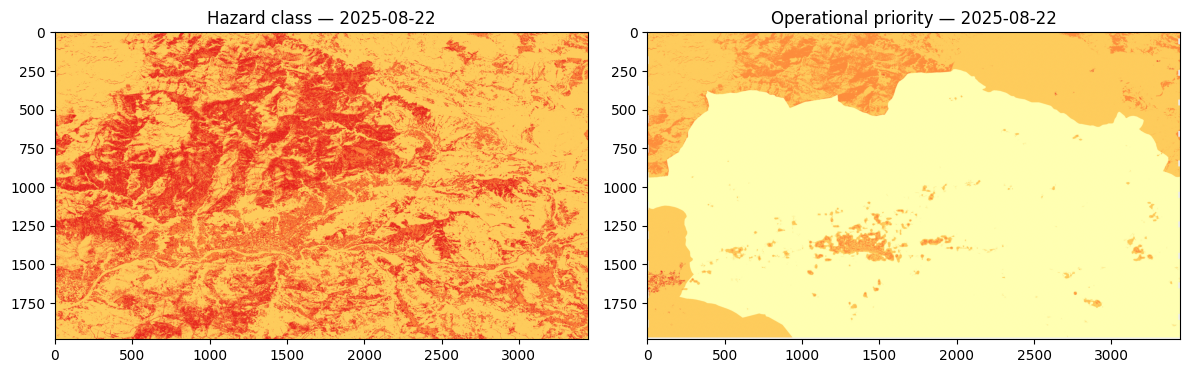

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap

last = written[-1]
pd.DataFrame([json.loads(last["analytics"].read_text())])
priority = rasterio.open(last["priority"]).read(1)
hazard_cls = rasterio.open(last["hazard_class"]).read(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cmap = ListedColormap(["#f0f0f0", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)
axes[0].imshow(hazard_cls, cmap=cmap, norm=norm)
axes[0].set_title(f"Hazard class — {last['date']}")
axes[1].imshow(priority, cmap=cmap, norm=norm)
axes[1].set_title(f"Operational priority — {last['date']}")
plt.tight_layout()
plt.show()